# Task 1 Results
Таблицы результатов и зависимости ошибок от гиперпараметров `rank` и `shape`.


In [55]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")


In [56]:
# Обычные CSV (1 ансамбль)
df_mtp = pl.read_csv("results_mtp.csv")
df_etn = pl.read_csv("results_etn.csv")

# rank/shape в исходных CSV не экранированы, поэтому читаем их компактно через rsplit.
def read_param_results(path: str, param_name: str) -> pl.DataFrame:
    metric_cols = [
        "train_energy_rmse", "train_energy_atom_rmse", "train_forces_rmse",
        "val_energy_rmse", "val_energy_atom_rmse", "val_forces_rmse", "train_time"
    ]
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        next(f)
        for line in f:
            left, *metrics = line.strip().rsplit(",", 7)
            pot_num, param_value = left.split(",", 1)
            rows.append({
                "pot_num": int(pot_num),
                param_name: param_value.strip(),
                **{k: float(v) for k, v in zip(metric_cols, metrics)}
            })
    return pl.DataFrame(rows)

df_etn_ranks = read_param_results("results_etn_ranks.csv", "rank")
df_etn_shape = read_param_results("results_etn_shape.csv", "shape")


## Таблицы: результаты 1 ансамбля


In [57]:
display(df_mtp)
display(df_etn)


pot_num,train_energy_rmse,train_energy_atom_rmse,train_forces_rmse,val_energy_rmse,val_energy_atom_rmse,val_forces_rmse,train_time
i64,f64,f64,f64,f64,f64,f64,f64
1,0.09327,0.002915,0.077761,0.161312,0.005041,0.120006,339.141607
2,0.077083,0.002409,0.074072,0.124319,0.003885,0.113015,364.969137
3,0.086659,0.002708,0.07386,0.12994,0.004061,0.110455,366.342474
4,0.07983,0.002495,0.060698,0.137284,0.00429,0.089316,369.009648
5,0.099781,0.003118,0.074714,0.173422,0.005419,0.115487,359.96218


pot_num,train_energy_rmse,train_energy_atom_rmse,train_forces_rmse,val_energy_rmse,val_energy_atom_rmse,val_forces_rmse,train_time
i64,f64,f64,f64,f64,f64,f64,f64
1,0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,59.706649
2,0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,88.322618
3,0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,47.788827
4,0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,50.36592
5,0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,48.064233


## Таблицы: результаты по параметрам


In [58]:
display(df_etn_ranks)
display(df_etn_shape)


pot_num,rank,train_energy_rmse,train_energy_atom_rmse,train_forces_rmse,val_energy_rmse,val_energy_atom_rmse,val_forces_rmse,train_time
i64,str,f64,f64,f64,f64,f64,f64,f64
1,"""[[1], [1]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,55.271899
2,"""[[1], [1]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,77.843226
3,"""[[1], [1]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,45.282596
4,"""[[1], [1]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,49.624292
5,"""[[1], [1]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,64.895653
…,…,…,…,…,…,…,…,…
1,"""[[3], [3]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,41.932044
2,"""[[3], [3]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,74.924844
3,"""[[3], [3]]""",0.275656,0.008614,0.191736,0.443984,0.013874,0.277115,52.209462


pot_num,shape,train_energy_rmse,train_energy_atom_rmse,train_forces_rmse,val_energy_rmse,val_energy_atom_rmse,val_forces_rmse,train_time
i64,str,f64,f64,f64,f64,f64,f64,f64
1,"""[[1], [4], [2]]""",0.733589,0.022925,0.544047,0.638169,0.019943,0.764686,45.712795
2,"""[[1], [4], [2]]""",0.733589,0.022925,0.544047,0.638169,0.019943,0.764686,41.522363
3,"""[[1], [4], [2]]""",0.733589,0.022925,0.544047,0.638169,0.019943,0.764686,39.61096
4,"""[[1], [4], [2]]""",0.733589,0.022925,0.544047,0.638169,0.019943,0.764686,51.314102
5,"""[[1], [4], [2]]""",0.733589,0.022925,0.544047,0.638169,0.019943,0.764686,35.812387
…,…,…,…,…,…,…,…,…
1,"""[[1], [8], [4]]""",0.215995,0.00675,0.120573,0.40267,0.012583,0.164119,86.803853
2,"""[[1], [8], [4]]""",0.215995,0.00675,0.120573,0.40267,0.012583,0.164119,77.05975
3,"""[[1], [8], [4]]""",0.215995,0.00675,0.120573,0.40267,0.012583,0.164119,69.048646


## Сводные таблицы (среднее по каждому значению параметра)


In [59]:
rank_summary = df_etn_ranks.group_by("rank").agg([
    pl.col("val_energy_rmse").mean().alias("val_energy_rmse_mean"),
    pl.col("val_forces_rmse").mean().alias("val_forces_rmse_mean"),
    pl.col("train_time").mean().alias("train_time_mean"),
]).sort("rank")

shape_summary = df_etn_shape.group_by("shape").agg([
    pl.col("val_energy_rmse").mean().alias("val_energy_rmse_mean"),
    pl.col("val_forces_rmse").mean().alias("val_forces_rmse_mean"),
    pl.col("train_time").mean().alias("train_time_mean"),
]).sort("shape")

display(rank_summary)
display(shape_summary)


rank,val_energy_rmse_mean,val_forces_rmse_mean,train_time_mean
str,f64,f64,f64
"""[[1], [1]]""",0.443984,0.277115,58.583533
"""[[2], [2]]""",0.443984,0.277115,58.625009
"""[[3], [3]]""",0.443984,0.277115,53.748894


shape,val_energy_rmse_mean,val_forces_rmse_mean,train_time_mean
str,f64,f64,f64
"""[[1], [4], [2]]""",0.638169,0.764686,42.794521
"""[[1], [6], [3]]""",0.443984,0.277115,57.987328
"""[[1], [8], [4]]""",0.40267,0.164119,73.02388


## График: val error от rank


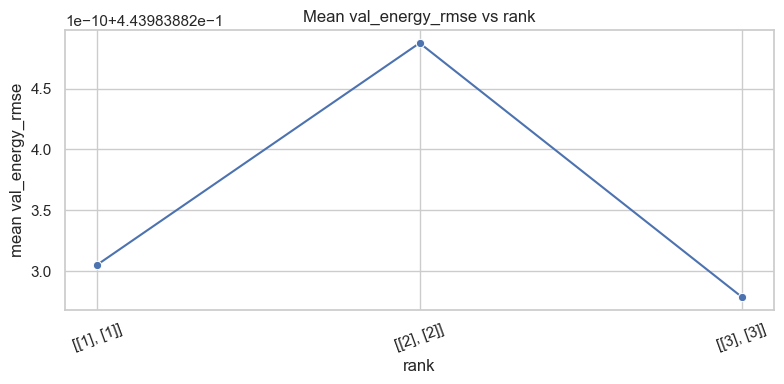

In [60]:
rank_plot_df = rank_summary.select(["rank", "val_energy_rmse_mean"]).to_pandas()
plt.figure(figsize=(8, 4))
sns.lineplot(data=rank_plot_df, x="rank", y="val_energy_rmse_mean", marker="o")
plt.title("Mean val_energy_rmse vs rank")
plt.xlabel("rank")
plt.ylabel("mean val_energy_rmse")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## График: val error от shape


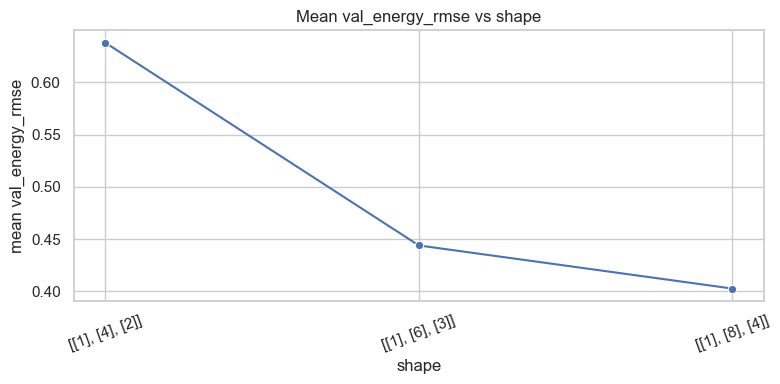

In [61]:
shape_plot_df = shape_summary.select(["shape", "val_energy_rmse_mean"]).to_pandas()
plt.figure(figsize=(8, 4))
sns.lineplot(data=shape_plot_df, x="shape", y="val_energy_rmse_mean", marker="o")
plt.title("Mean val_energy_rmse vs shape")
plt.xlabel("shape")
plt.ylabel("mean val_energy_rmse")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
